In [11]:
import time
import csv
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f"Đang sử dụng GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
else:
    print("Không tìm thấy GPU, sử dụng CPU")

Không tìm thấy GPU, sử dụng CPU


In [13]:
# ----- Cấu hình-----
latent_dim = 100
batch_size = 256 if torch.cuda.is_available() else 64
lr = 0.0003
epochs = 300

# For MNIST (grayscale)
nc = 1  # number of channels = 1 for MNIST
ngf = 64
ndf = 32

In [14]:
# ----- Dataset -----
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
train_loader = DataLoader(
    datasets.MNIST('.', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True,
    pin_memory=True if device.type == 'cuda' else False
)

In [15]:
# ----- Weight init -----
def init_weights(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# ----- Generator (designed for 28x28 MNIST) -----
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        # We'll go: 1x1 -> 7x7 -> 14x14 -> 28x28
        self.model = nn.Sequential(
            # input: (N, latent_dim, 1, 1)
            nn.ConvTranspose2d(latent_dim, 64, kernel_size=7, stride=1, padding=0, bias=False),  # -> 7x7
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 4, kernel_size=4, stride=2, padding=1, bias=False),  # -> 14x14
            nn.BatchNorm2d(4),
            nn.ReLU(True),

            nn.ConvTranspose2d(4, nc, kernel_size=4, stride=2, padding=1, bias=False),   # -> 28x28
            nn.Tanh()  # output in [-1, 1]
        )

    def forward(self, z):
        # expect z shape (N, latent_dim) or (N, latent_dim, 1, 1)
        if z.dim() == 2:
            z = z.view(z.size(0), z.size(1), 1, 1)
        return self.model(z)

# ----- Discriminator (matching 28x28 input) -----
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # 28x28 -> 14x14 -> 7x7 -> 1x1
        self.model = nn.Sequential(
            nn.Conv2d(nc, ndf, kernel_size=4, stride=2, padding=1, bias=False),  # -> 14x14
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 10, kernel_size=4, stride=2, padding=1, bias=False),  # -> 7x7
            nn.BatchNorm2d(ndf * 10),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 10, 1, kernel_size=7, stride=1, padding=0, bias=False),  # -> 1x1
            nn.Sigmoid()
        )

    def forward(self, img):
        out = self.model(img)           # (N,1,1,1)
        return out.view(img.size(0), 1) # (N,1) to match your BCELoss targets

In [16]:
# ----- Khởi tạo mô hình và tối ưu hóa -----
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

generator.apply(init_weights)
discriminator.apply(init_weights)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

In [17]:
def model_params_size_bytes(model):
    params = sum(p.numel() * p.element_size() for p in model.parameters())
    buffers = sum(b.numel() * b.element_size() for b in model.buffers())
    return params + buffers

def n_paramters_approx(n_MB: float):
    n_Bytes = int(n_MB * (1024**2))
    n_parameters = n_Bytes // 4 #Cho rằng các tham số có kiểu dữ liệu float32
    
    return int(n_parameters)

def bytes_to_mb(b):
    return b / (1024**2)

generator_parameters_size = bytes_to_mb(model_params_size_bytes(generator))
discriminator_parameters_size = bytes_to_mb(model_params_size_bytes(discriminator))
total_size = generator_parameters_size + discriminator_parameters_size
print(f"Numbers of parameters: {n_paramters_approx(total_size):,}")

print(f"Model size (MB):\n\tGenerator: {generator_parameters_size:.2f} (MB)\n\tDiscriminator: {discriminator_parameters_size:.2f} (MB)\n\tTotal: {total_size:.2f} (MB)")


Numbers of parameters: 499,350
Model size (MB):
	Generator: 1.21 (MB)
	Discriminator: 0.69 (MB)
	Total: 1.90 (MB)


In [18]:
# Storage for metrics
history = {'epoch': 0, 'loss_D': [], 'loss_G': [], 'epoch_time_sec': []}

[Epoch 1/300] Loss_D: 0.0076, Loss_G: 6.2376, Time: 58.35s


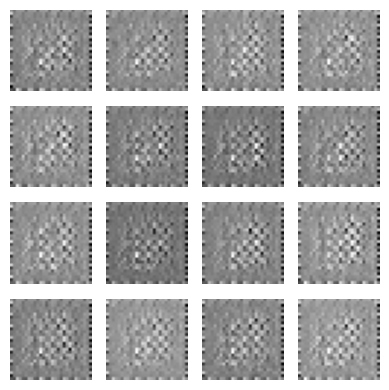

[Epoch 2/300] Loss_D: 0.0001, Loss_G: 9.3542, Time: 115.38s
[Epoch 3/300] Loss_D: 0.0000, Loss_G: 10.3648, Time: 175.15s
[Epoch 4/300] Loss_D: 0.0000, Loss_G: 11.3105, Time: 232.19s
[Epoch 5/300] Loss_D: 0.0170, Loss_G: 7.1968, Time: 302.79s
[Epoch 6/300] Loss_D: 0.0027, Loss_G: 6.3902, Time: 380.26s
[Epoch 7/300] Loss_D: 0.0344, Loss_G: 5.9731, Time: 458.59s
[Epoch 8/300] Loss_D: 0.0221, Loss_G: 5.1334, Time: 536.71s
[Epoch 9/300] Loss_D: 0.0415, Loss_G: 5.0543, Time: 614.45s
[Epoch 10/300] Loss_D: 0.0333, Loss_G: 5.0137, Time: 691.74s
[Epoch 11/300] Loss_D: 0.0426, Loss_G: 5.1993, Time: 769.77s
[Epoch 12/300] Loss_D: 0.0525, Loss_G: 5.1502, Time: 847.74s
[Epoch 13/300] Loss_D: 0.0443, Loss_G: 5.1939, Time: 926.03s
[Epoch 14/300] Loss_D: 0.0592, Loss_G: 5.2761, Time: 1001.77s
[Epoch 15/300] Loss_D: 0.0281, Loss_G: 5.3178, Time: 1071.76s
[Epoch 16/300] Loss_D: 0.0444, Loss_G: 5.5275, Time: 1127.83s
[Epoch 17/300] Loss_D: 0.0573, Loss_G: 5.4985, Time: 1187.87s
[Epoch 18/300] Loss_D: 0.0

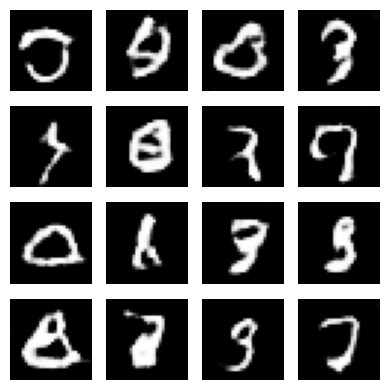

[Epoch 21/300] Loss_D: 0.0292, Loss_G: 5.9764, Time: 1450.21s
[Epoch 22/300] Loss_D: 0.0260, Loss_G: 6.2103, Time: 1527.98s
[Epoch 23/300] Loss_D: 0.0656, Loss_G: 6.3897, Time: 1606.42s
[Epoch 24/300] Loss_D: 0.0317, Loss_G: 5.8720, Time: 1684.36s
[Epoch 25/300] Loss_D: 0.0095, Loss_G: 6.5383, Time: 1762.74s
[Epoch 26/300] Loss_D: 0.0711, Loss_G: 6.0918, Time: 1839.05s
[Epoch 27/300] Loss_D: 0.0109, Loss_G: 6.4081, Time: 1914.76s
[Epoch 28/300] Loss_D: 0.1074, Loss_G: 5.0158, Time: 1991.23s
[Epoch 29/300] Loss_D: 0.0294, Loss_G: 5.3410, Time: 2068.35s
[Epoch 30/300] Loss_D: 0.0586, Loss_G: 5.7526, Time: 2145.44s
[Epoch 31/300] Loss_D: 0.0194, Loss_G: 5.8752, Time: 2222.57s
[Epoch 32/300] Loss_D: 0.0218, Loss_G: 6.2024, Time: 2296.95s
[Epoch 33/300] Loss_D: 0.0628, Loss_G: 6.5789, Time: 2374.13s
[Epoch 34/300] Loss_D: 0.0152, Loss_G: 6.3436, Time: 2450.95s
[Epoch 35/300] Loss_D: 0.0090, Loss_G: 6.8063, Time: 2529.42s
[Epoch 36/300] Loss_D: 0.0276, Loss_G: 6.8381, Time: 2607.33s
[Epoch 3

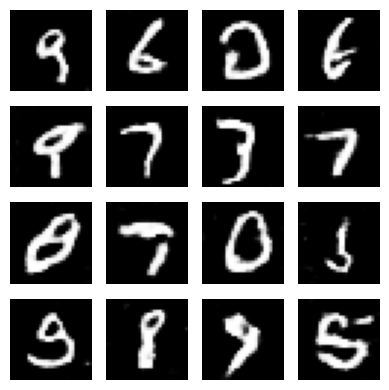

[Epoch 41/300] Loss_D: 0.0106, Loss_G: 7.3553, Time: 2993.63s
[Epoch 42/300] Loss_D: 0.0262, Loss_G: 7.5082, Time: 3072.74s
[Epoch 43/300] Loss_D: 0.0243, Loss_G: 7.0981, Time: 3150.25s
[Epoch 44/300] Loss_D: 0.0095, Loss_G: 7.4214, Time: 3227.33s
[Epoch 45/300] Loss_D: 0.0249, Loss_G: 7.1328, Time: 3304.08s
[Epoch 46/300] Loss_D: 0.0210, Loss_G: 7.7101, Time: 3380.64s
[Epoch 47/300] Loss_D: 0.0100, Loss_G: 7.6183, Time: 3457.30s
[Epoch 48/300] Loss_D: 0.0524, Loss_G: 7.7419, Time: 3534.61s
[Epoch 49/300] Loss_D: 0.0138, Loss_G: 6.5289, Time: 3613.48s
[Epoch 50/300] Loss_D: 0.0088, Loss_G: 7.5359, Time: 3683.75s
[Epoch 51/300] Loss_D: 0.0452, Loss_G: 7.9837, Time: 3761.13s
[Epoch 52/300] Loss_D: 0.0314, Loss_G: 6.9779, Time: 3837.31s
[Epoch 53/300] Loss_D: 0.0062, Loss_G: 7.5561, Time: 3915.46s
[Epoch 54/300] Loss_D: 0.0248, Loss_G: 7.5911, Time: 3992.40s
[Epoch 55/300] Loss_D: 0.0090, Loss_G: 7.8641, Time: 4069.93s
[Epoch 56/300] Loss_D: 0.0046, Loss_G: 8.1616, Time: 4147.92s
[Epoch 5

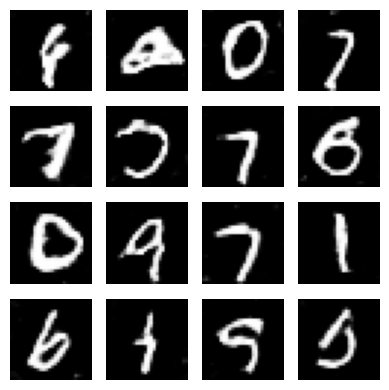

[Epoch 61/300] Loss_D: 0.0055, Loss_G: 7.7264, Time: 4531.03s
[Epoch 62/300] Loss_D: 0.0048, Loss_G: 8.2507, Time: 4608.83s
[Epoch 63/300] Loss_D: 0.0370, Loss_G: 7.9780, Time: 4685.74s
[Epoch 64/300] Loss_D: 0.0033, Loss_G: 8.2546, Time: 4763.78s
[Epoch 65/300] Loss_D: 0.0091, Loss_G: 8.3740, Time: 4840.58s
[Epoch 66/300] Loss_D: 0.0354, Loss_G: 7.6956, Time: 4917.98s
[Epoch 67/300] Loss_D: 0.0046, Loss_G: 7.9154, Time: 4996.00s
[Epoch 68/300] Loss_D: 0.0082, Loss_G: 8.2662, Time: 5073.71s
[Epoch 69/300] Loss_D: 0.0186, Loss_G: 8.1988, Time: 5150.61s
[Epoch 70/300] Loss_D: 0.0019, Loss_G: 8.8620, Time: 5221.43s
[Epoch 71/300] Loss_D: 0.0116, Loss_G: 8.9931, Time: 5298.38s
[Epoch 72/300] Loss_D: 0.0041, Loss_G: 8.8397, Time: 5375.42s
[Epoch 73/300] Loss_D: 0.0697, Loss_G: 7.2830, Time: 5435.20s
[Epoch 74/300] Loss_D: 0.0080, Loss_G: 7.2173, Time: 5494.20s
[Epoch 75/300] Loss_D: 0.0085, Loss_G: 7.8921, Time: 5552.55s
[Epoch 76/300] Loss_D: 0.0034, Loss_G: 8.4123, Time: 5611.77s
[Epoch 7

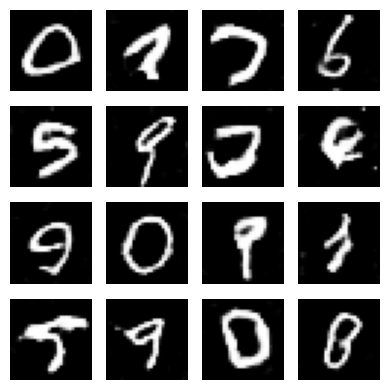

[Epoch 81/300] Loss_D: 0.0033, Loss_G: 8.3088, Time: 5999.33s
[Epoch 82/300] Loss_D: 0.0183, Loss_G: 8.5307, Time: 6076.20s
[Epoch 83/300] Loss_D: 0.0027, Loss_G: 8.7841, Time: 6153.93s
[Epoch 84/300] Loss_D: 0.0291, Loss_G: 9.3435, Time: 6231.93s
[Epoch 85/300] Loss_D: 0.0109, Loss_G: 8.4893, Time: 6308.89s
[Epoch 86/300] Loss_D: 0.0017, Loss_G: 9.0065, Time: 6386.64s
[Epoch 87/300] Loss_D: 0.0148, Loss_G: 9.0954, Time: 6456.73s
[Epoch 88/300] Loss_D: 0.0025, Loss_G: 9.0451, Time: 6533.51s
[Epoch 89/300] Loss_D: 0.0109, Loss_G: 9.1806, Time: 6610.41s
[Epoch 90/300] Loss_D: 0.0016, Loss_G: 9.4030, Time: 6685.40s
[Epoch 91/300] Loss_D: 0.0405, Loss_G: 9.3230, Time: 6761.68s
[Epoch 92/300] Loss_D: 0.0071, Loss_G: 8.0116, Time: 6839.07s
[Epoch 93/300] Loss_D: 0.0024, Loss_G: 8.8197, Time: 6913.70s
[Epoch 94/300] Loss_D: 0.0016, Loss_G: 9.2759, Time: 6989.25s
[Epoch 95/300] Loss_D: 0.0289, Loss_G: 8.7897, Time: 7065.12s
[Epoch 96/300] Loss_D: 0.0026, Loss_G: 8.8967, Time: 7142.35s
[Epoch 9

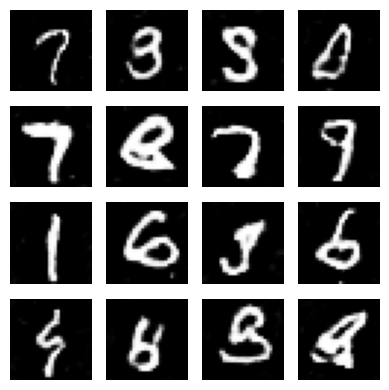

[Epoch 101/300] Loss_D: 0.0019, Loss_G: 9.0367, Time: 7526.93s
[Epoch 102/300] Loss_D: 0.0377, Loss_G: 8.6565, Time: 7603.84s
[Epoch 103/300] Loss_D: 0.0039, Loss_G: 8.3126, Time: 7663.78s
[Epoch 104/300] Loss_D: 0.0028, Loss_G: 9.1022, Time: 7725.62s
[Epoch 105/300] Loss_D: 0.0034, Loss_G: 9.5262, Time: 7784.91s
[Epoch 106/300] Loss_D: 0.0157, Loss_G: 9.0554, Time: 7841.45s
[Epoch 107/300] Loss_D: 0.0067, Loss_G: 9.4911, Time: 7907.74s
[Epoch 108/300] Loss_D: 0.0461, Loss_G: 9.5316, Time: 7984.41s
[Epoch 109/300] Loss_D: 0.0299, Loss_G: 7.3293, Time: 8061.69s
[Epoch 110/300] Loss_D: 0.0040, Loss_G: 8.0729, Time: 8131.22s
[Epoch 111/300] Loss_D: 0.0021, Loss_G: 8.7852, Time: 8208.24s
[Epoch 112/300] Loss_D: 0.0120, Loss_G: 8.9631, Time: 8285.03s
[Epoch 113/300] Loss_D: 0.0019, Loss_G: 9.3053, Time: 8362.45s
[Epoch 114/300] Loss_D: 0.0197, Loss_G: 8.6336, Time: 8439.39s
[Epoch 115/300] Loss_D: 0.0019, Loss_G: 9.2360, Time: 8515.97s
[Epoch 116/300] Loss_D: 0.0110, Loss_G: 9.3961, Time: 8

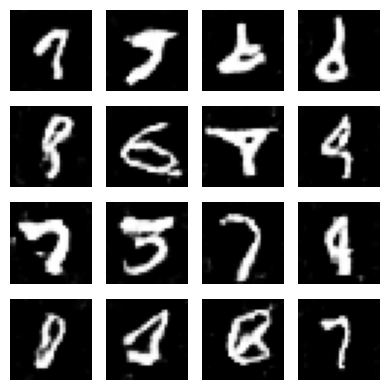

[Epoch 121/300] Loss_D: 0.0023, Loss_G: 9.0436, Time: 8893.33s
[Epoch 122/300] Loss_D: 0.0307, Loss_G: 9.4426, Time: 8971.42s
[Epoch 123/300] Loss_D: 0.0036, Loss_G: 8.8865, Time: 9046.58s
[Epoch 124/300] Loss_D: 0.0018, Loss_G: 9.4110, Time: 9124.43s
[Epoch 125/300] Loss_D: 0.0413, Loss_G: 9.8306, Time: 9201.98s
[Epoch 126/300] Loss_D: 0.0238, Loss_G: 7.7371, Time: 9279.33s
[Epoch 127/300] Loss_D: 0.0029, Loss_G: 8.5454, Time: 9356.18s
[Epoch 128/300] Loss_D: 0.0024, Loss_G: 9.1064, Time: 9433.76s
[Epoch 129/300] Loss_D: 0.0193, Loss_G: 9.4664, Time: 9511.96s
[Epoch 130/300] Loss_D: 0.0044, Loss_G: 8.9044, Time: 9588.01s
[Epoch 131/300] Loss_D: 0.0022, Loss_G: 9.5423, Time: 9666.21s
[Epoch 132/300] Loss_D: 0.0009, Loss_G: 9.8966, Time: 9742.96s
[Epoch 133/300] Loss_D: 0.0355, Loss_G: 8.6359, Time: 9820.85s
[Epoch 134/300] Loss_D: 0.0014, Loss_G: 9.2574, Time: 9898.06s
[Epoch 135/300] Loss_D: 0.0009, Loss_G: 9.7979, Time: 9975.84s
[Epoch 136/300] Loss_D: 0.0277, Loss_G: 9.2567, Time: 1

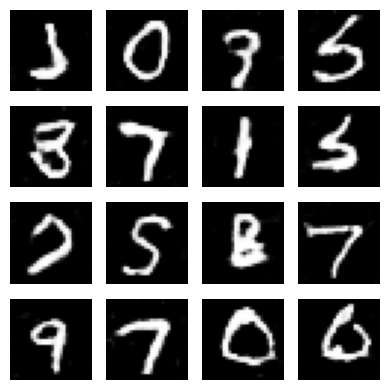

[Epoch 141/300] Loss_D: 0.0015, Loss_G: 9.5154, Time: 10433.07s
[Epoch 142/300] Loss_D: 0.0018, Loss_G: 10.0068, Time: 10510.55s
[Epoch 143/300] Loss_D: 0.0262, Loss_G: 10.1494, Time: 10588.70s
[Epoch 144/300] Loss_D: 0.0027, Loss_G: 9.1927, Time: 10665.78s
[Epoch 145/300] Loss_D: 0.0015, Loss_G: 9.8596, Time: 10733.88s
[Epoch 146/300] Loss_D: 0.0061, Loss_G: 9.8590, Time: 10793.66s
[Epoch 147/300] Loss_D: 0.0009, Loss_G: 10.2555, Time: 10852.63s
[Epoch 148/300] Loss_D: 0.0200, Loss_G: 10.1855, Time: 10912.62s
[Epoch 149/300] Loss_D: 0.0032, Loss_G: 9.4260, Time: 10973.32s
[Epoch 150/300] Loss_D: 0.0010, Loss_G: 10.0650, Time: 11039.59s
[Epoch 151/300] Loss_D: 0.0120, Loss_G: 10.3270, Time: 11116.46s
[Epoch 152/300] Loss_D: 0.0042, Loss_G: 9.9761, Time: 11193.79s
[Epoch 153/300] Loss_D: 0.0010, Loss_G: 10.3876, Time: 11272.30s
[Epoch 154/300] Loss_D: 0.0269, Loss_G: 9.1052, Time: 11350.21s
[Epoch 155/300] Loss_D: 0.0012, Loss_G: 9.6576, Time: 11427.79s
[Epoch 156/300] Loss_D: 0.0008, L

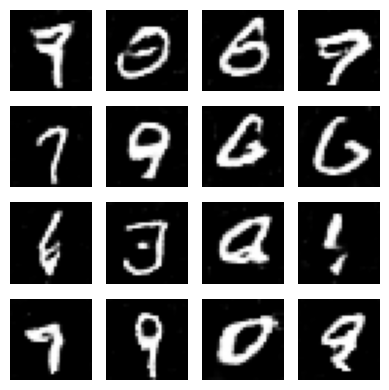

[Epoch 161/300] Loss_D: 0.0094, Loss_G: 10.5549, Time: 11818.12s
[Epoch 162/300] Loss_D: 0.0024, Loss_G: 9.8259, Time: 11894.78s
[Epoch 163/300] Loss_D: 0.0021, Loss_G: 10.4900, Time: 11972.26s
[Epoch 164/300] Loss_D: 0.0282, Loss_G: 9.6720, Time: 12050.94s
[Epoch 165/300] Loss_D: 0.0009, Loss_G: 10.1083, Time: 12127.17s
[Epoch 166/300] Loss_D: 0.0009, Loss_G: 10.4894, Time: 12205.47s
[Epoch 167/300] Loss_D: 0.0006, Loss_G: 10.8336, Time: 12282.40s
[Epoch 168/300] Loss_D: 0.0136, Loss_G: 10.3150, Time: 12360.91s
[Epoch 169/300] Loss_D: 0.0012, Loss_G: 10.4804, Time: 12438.80s
[Epoch 170/300] Loss_D: 0.0006, Loss_G: 10.7702, Time: 12516.60s
[Epoch 171/300] Loss_D: 0.0247, Loss_G: 9.7243, Time: 12593.04s
[Epoch 172/300] Loss_D: 0.0010, Loss_G: 10.0742, Time: 12670.32s
[Epoch 173/300] Loss_D: 0.0032, Loss_G: 10.5891, Time: 12748.65s
[Epoch 174/300] Loss_D: 0.0099, Loss_G: 10.5841, Time: 12826.60s
[Epoch 175/300] Loss_D: 0.0007, Loss_G: 10.6568, Time: 12905.25s
[Epoch 176/300] Loss_D: 0.08

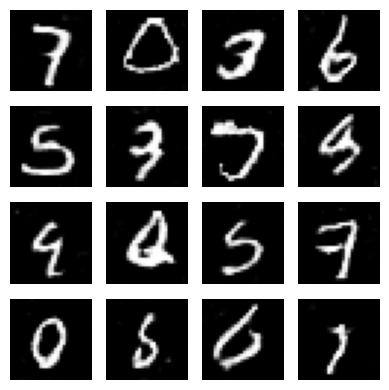

[Epoch 181/300] Loss_D: 0.0056, Loss_G: 9.2459, Time: 13371.18s
[Epoch 182/300] Loss_D: 0.0012, Loss_G: 9.8511, Time: 13449.63s
[Epoch 183/300] Loss_D: 0.0008, Loss_G: 10.3627, Time: 13528.33s
[Epoch 184/300] Loss_D: 0.0123, Loss_G: 10.0996, Time: 13605.85s
[Epoch 185/300] Loss_D: 0.0009, Loss_G: 10.3803, Time: 13683.27s
[Epoch 186/300] Loss_D: 0.0466, Loss_G: 10.1066, Time: 13759.60s
[Epoch 187/300] Loss_D: 0.0030, Loss_G: 9.0590, Time: 13838.76s
[Epoch 188/300] Loss_D: 0.0012, Loss_G: 9.8353, Time: 13915.81s
[Epoch 189/300] Loss_D: 0.0008, Loss_G: 10.2747, Time: 13993.74s
[Epoch 190/300] Loss_D: 0.0022, Loss_G: 10.5076, Time: 14071.68s
[Epoch 191/300] Loss_D: 0.0215, Loss_G: 9.9102, Time: 14149.59s
[Epoch 192/300] Loss_D: 0.0012, Loss_G: 9.9564, Time: 14227.64s
[Epoch 193/300] Loss_D: 0.0007, Loss_G: 10.5177, Time: 14305.09s
[Epoch 194/300] Loss_D: 0.0005, Loss_G: 10.7449, Time: 14375.34s
[Epoch 195/300] Loss_D: 0.0215, Loss_G: 10.0339, Time: 14452.10s
[Epoch 196/300] Loss_D: 0.0015,

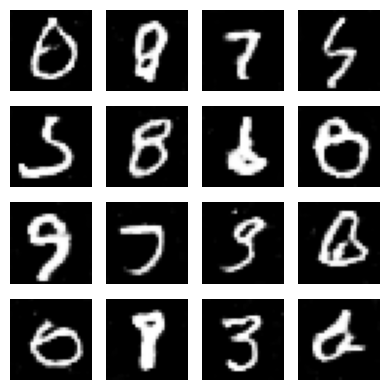

[Epoch 201/300] Loss_D: 0.0067, Loss_G: 10.7044, Time: 14893.68s
[Epoch 202/300] Loss_D: 0.0007, Loss_G: 10.7572, Time: 14953.47s
[Epoch 203/300] Loss_D: 0.0228, Loss_G: 9.8286, Time: 15013.73s
[Epoch 204/300] Loss_D: 0.0011, Loss_G: 10.2588, Time: 15072.93s
[Epoch 205/300] Loss_D: 0.0005, Loss_G: 10.7381, Time: 15131.39s
[Epoch 206/300] Loss_D: 0.0050, Loss_G: 10.9029, Time: 15190.40s
[Epoch 207/300] Loss_D: 0.0015, Loss_G: 10.7579, Time: 15249.88s
[Epoch 208/300] Loss_D: 0.0285, Loss_G: 10.5178, Time: 15310.71s
[Epoch 209/300] Loss_D: 0.0021, Loss_G: 9.5975, Time: 15367.94s
[Epoch 210/300] Loss_D: 0.0010, Loss_G: 10.3010, Time: 15429.80s
[Epoch 211/300] Loss_D: 0.0435, Loss_G: 10.2865, Time: 15489.50s
[Epoch 212/300] Loss_D: 0.0028, Loss_G: 9.2903, Time: 15547.60s
[Epoch 213/300] Loss_D: 0.0012, Loss_G: 10.0370, Time: 15608.39s
[Epoch 214/300] Loss_D: 0.0009, Loss_G: 10.5646, Time: 15666.15s
[Epoch 215/300] Loss_D: 0.0148, Loss_G: 10.6210, Time: 15726.06s
[Epoch 216/300] Loss_D: 0.00

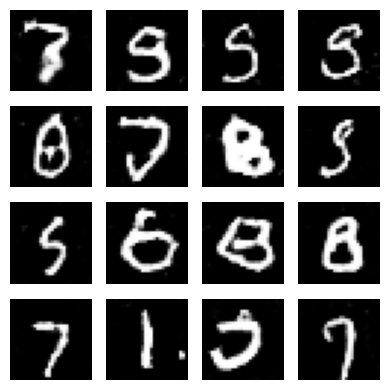

[Epoch 221/300] Loss_D: 0.0006, Loss_G: 10.7880, Time: 16082.81s
[Epoch 222/300] Loss_D: 0.0009, Loss_G: 11.1538, Time: 16142.44s
[Epoch 223/300] Loss_D: 0.0245, Loss_G: 10.2778, Time: 16201.35s
[Epoch 224/300] Loss_D: 0.0013, Loss_G: 10.2828, Time: 16260.61s
[Epoch 225/300] Loss_D: 0.0006, Loss_G: 10.7245, Time: 16320.81s
[Epoch 226/300] Loss_D: 0.0005, Loss_G: 11.0124, Time: 16380.22s
[Epoch 227/300] Loss_D: 0.0288, Loss_G: 10.5910, Time: 16441.06s
[Epoch 228/300] Loss_D: 0.0019, Loss_G: 9.6429, Time: 16499.62s
[Epoch 229/300] Loss_D: 0.0009, Loss_G: 10.2632, Time: 16560.87s
[Epoch 230/300] Loss_D: 0.0224, Loss_G: 10.0906, Time: 16620.05s
[Epoch 231/300] Loss_D: 0.0012, Loss_G: 10.0483, Time: 16677.50s
[Epoch 232/300] Loss_D: 0.0007, Loss_G: 10.5720, Time: 16738.92s
[Epoch 233/300] Loss_D: 0.0113, Loss_G: 10.9703, Time: 16796.92s
[Epoch 234/300] Loss_D: 0.0210, Loss_G: 9.2946, Time: 16857.45s
[Epoch 235/300] Loss_D: 0.0013, Loss_G: 9.9681, Time: 16915.40s
[Epoch 236/300] Loss_D: 0.00

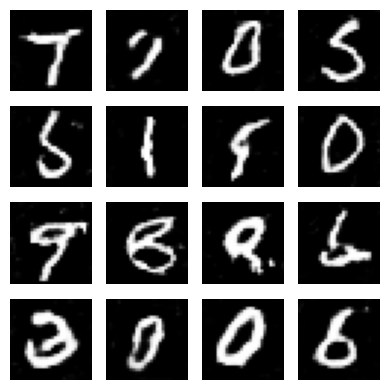

[Epoch 241/300] Loss_D: 0.0147, Loss_G: 10.8584, Time: 17946.54s
[Epoch 242/300] Loss_D: 0.0013, Loss_G: 10.2869, Time: 18188.87s
[Epoch 243/300] Loss_D: 0.0005, Loss_G: 10.8572, Time: 18339.16s
[Epoch 244/300] Loss_D: 0.0005, Loss_G: 11.1137, Time: 18399.34s
[Epoch 245/300] Loss_D: 0.0161, Loss_G: 10.5307, Time: 18457.84s
[Epoch 246/300] Loss_D: 0.0008, Loss_G: 10.7086, Time: 18517.80s
[Epoch 247/300] Loss_D: 0.0102, Loss_G: 11.0960, Time: 18583.93s
[Epoch 248/300] Loss_D: 0.0149, Loss_G: 10.2852, Time: 18661.66s
[Epoch 249/300] Loss_D: 0.0010, Loss_G: 10.5046, Time: 18738.97s
[Epoch 250/300] Loss_D: 0.0006, Loss_G: 10.9729, Time: 18809.73s
[Epoch 251/300] Loss_D: 0.0028, Loss_G: 11.1220, Time: 18868.44s
[Epoch 252/300] Loss_D: 0.0177, Loss_G: 11.1074, Time: 18929.23s
[Epoch 253/300] Loss_D: 0.0010, Loss_G: 10.5376, Time: 18986.09s
[Epoch 254/300] Loss_D: 0.0006, Loss_G: 11.0550, Time: 19048.31s
[Epoch 255/300] Loss_D: 0.0093, Loss_G: 11.1991, Time: 19122.23s
[Epoch 256/300] Loss_D: 0

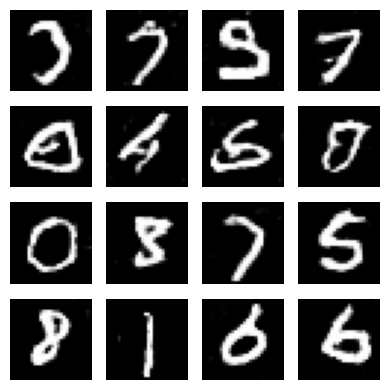

[Epoch 261/300] Loss_D: 0.0010, Loss_G: 11.0671, Time: 19577.99s
[Epoch 262/300] Loss_D: 0.0007, Loss_G: 11.3855, Time: 19653.45s
[Epoch 263/300] Loss_D: 0.0213, Loss_G: 10.6805, Time: 19727.98s
[Epoch 264/300] Loss_D: 0.0011, Loss_G: 10.5212, Time: 19805.20s
[Epoch 265/300] Loss_D: 0.0005, Loss_G: 11.0577, Time: 19882.26s
[Epoch 266/300] Loss_D: 0.0265, Loss_G: 9.8007, Time: 19957.31s
[Epoch 267/300] Loss_D: 0.0013, Loss_G: 10.3440, Time: 20017.63s
[Epoch 268/300] Loss_D: 0.0007, Loss_G: 10.8040, Time: 20076.78s
[Epoch 269/300] Loss_D: 0.0006, Loss_G: 11.1815, Time: 20137.03s
[Epoch 270/300] Loss_D: 0.0060, Loss_G: 10.9744, Time: 20197.14s
[Epoch 271/300] Loss_D: 0.0140, Loss_G: 10.6958, Time: 20266.41s
[Epoch 272/300] Loss_D: 0.0006, Loss_G: 11.0059, Time: 20342.50s
[Epoch 273/300] Loss_D: 0.0043, Loss_G: 11.1790, Time: 20418.34s
[Epoch 274/300] Loss_D: 0.0007, Loss_G: 11.2702, Time: 20494.66s
[Epoch 275/300] Loss_D: 0.0005, Loss_G: 11.7056, Time: 20571.16s
[Epoch 276/300] Loss_D: 0.

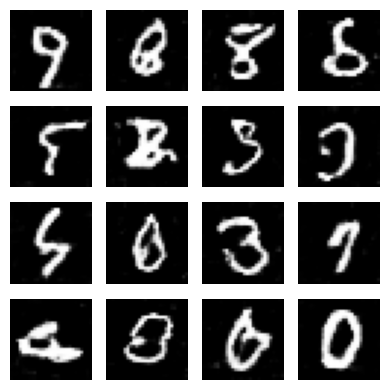

[Epoch 281/300] Loss_D: 0.0017, Loss_G: 10.1987, Time: 21033.76s
[Epoch 282/300] Loss_D: 0.0011, Loss_G: 10.7065, Time: 21096.81s
[Epoch 283/300] Loss_D: 0.0011, Loss_G: 11.0950, Time: 21154.51s
[Epoch 284/300] Loss_D: 0.0143, Loss_G: 11.5180, Time: 21213.02s
[Epoch 285/300] Loss_D: 0.0030, Loss_G: 10.7689, Time: 21272.83s
[Epoch 286/300] Loss_D: 0.0008, Loss_G: 11.2461, Time: 21332.77s
[Epoch 287/300] Loss_D: 0.0004, Loss_G: 11.6335, Time: 21395.19s
[Epoch 288/300] Loss_D: 0.0223, Loss_G: 10.6538, Time: 21454.59s
[Epoch 289/300] Loss_D: 0.0015, Loss_G: 10.4389, Time: 21517.62s
[Epoch 290/300] Loss_D: 0.0014, Loss_G: 10.9297, Time: 21577.11s
[Epoch 291/300] Loss_D: 0.0004, Loss_G: 11.5293, Time: 21637.25s
[Epoch 292/300] Loss_D: 0.0254, Loss_G: 11.4468, Time: 21696.77s
[Epoch 293/300] Loss_D: 0.0018, Loss_G: 10.4136, Time: 21754.44s
[Epoch 294/300] Loss_D: 0.0023, Loss_G: 11.0180, Time: 21964.90s
[Epoch 295/300] Loss_D: 0.0007, Loss_G: 11.4730, Time: 22211.15s
[Epoch 296/300] Loss_D: 0

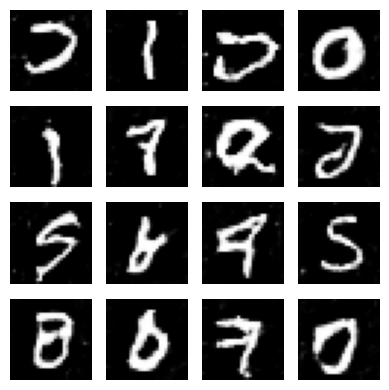

In [19]:
# ----- Training loop-----
t0 = time.perf_counter()
for epoch in range(1, epochs + 1):
    epoch_loss_D = 0.0
    epoch_loss_G = 0.0

    for real_imgs, _ in train_loader:
        real_imgs = real_imgs.to(device, non_blocking=True)
        b = real_imgs.size(0)

        valid = torch.ones(b, 1, device=device)
        fake = torch.zeros(b, 1, device=device)

        # -- Discriminator
        optimizer_D.zero_grad()
        loss_real = criterion(discriminator(real_imgs), valid)

        z = torch.randn(b, latent_dim, device=device)
        gen_imgs = generator(z)  # generator returns (b,1,28,28)
        loss_fake = criterion(discriminator(gen_imgs.detach()), fake)

        loss_D = 0.5 * (loss_real + loss_fake)
        loss_D.backward()
        optimizer_D.step()

        # -- Generator
        optimizer_G.zero_grad()
        loss_G = criterion(discriminator(gen_imgs), valid)
        loss_G.backward()
        optimizer_G.step()

        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()

    avg_loss_D = epoch_loss_D / len(train_loader)
    avg_loss_G = epoch_loss_G / len(train_loader)
    elapsed = time.perf_counter() - t0

    history['epoch'] += 1
    history['loss_D'].append(avg_loss_D)
    history['loss_G'].append(avg_loss_G)
    history['epoch_time_sec'].append(elapsed)

    print(f"[Epoch {epoch}/{epochs}] Loss_D: {avg_loss_D:.4f}, Loss_G: {avg_loss_G:.4f}, Time: {elapsed:.2f}s")

    if epoch % 20 == 0 or epoch == 1:
        with torch.no_grad():
            test_z = torch.randn(16, latent_dim, device=device)
            test_imgs = generator(test_z).cpu()
            fig, axes = plt.subplots(4, 4, figsize=(4, 4))
            for img, ax in zip(test_imgs, axes.flatten()):
                ax.imshow(img.squeeze() * 0.5 + 0.5, cmap='gray')
                ax.axis('off')
            plt.tight_layout()
            plt.show()

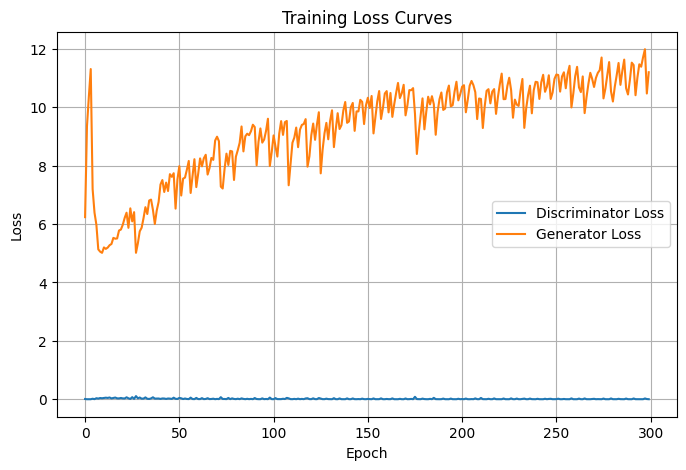

In [20]:
# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(300), history['loss_D'], label='Discriminator Loss')
plt.plot(range(300), history['loss_G'], label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss Curves')
plt.grid(True)
plt.show()

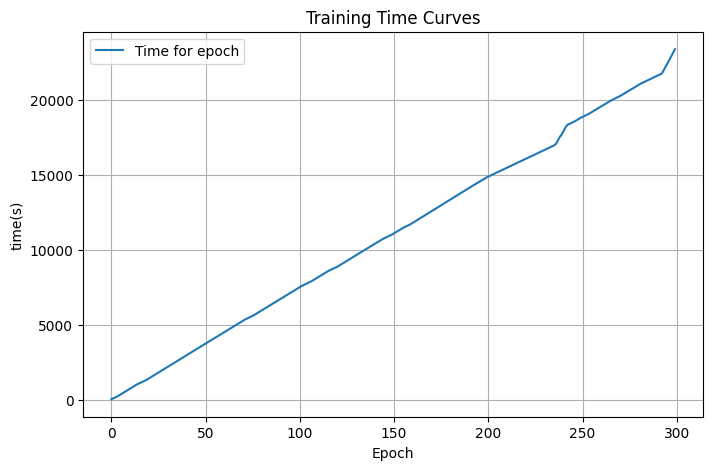

In [21]:
# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(300), history['epoch_time_sec'], label='Time for epoch')
plt.xlabel('Epoch')
plt.ylabel('time(s)')
plt.legend()
plt.title('Training Time Curves')
plt.grid(True)
plt.show()

In [22]:
# Export to CSV
csv_file = 'DCGAN_training_history.csv'
with open(csv_file, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['epoch', 'loss_D', 'loss_G', 'epoch_time_sec'])
    writer.writeheader()
    for e, ld, lg, t in zip(range(history['epoch']), history['loss_D'], history['loss_G'], history['epoch_time_sec']):
        writer.writerow({'epoch': e, 'loss_D': ld, 'loss_G': lg, 'epoch_time_sec': t})

print(f"Training history exported to {csv_file}")

Training history exported to DCGAN_training_history.csv


In [23]:
import os
def read_history_from_file(path, history):
    """
    Read training history from a CSV or JSON file and merge into `history` dict.
    - `path`: path to CSV or JSON file (supports .csv and .json).
    - `history`: dict expected to contain at least 'epoch' and some list fields, e.g.
        {'epoch': 0, 'loss_D': [], 'loss_G': [], 'epoch_time_sec': []}
    Returns updated history (same object).
    """
    if not os.path.isfile(path):
        raise FileNotFoundError(f"No file at: {path}")

    ext = os.path.splitext(path)[1].lower()
    rows = []

    if ext == '.csv':
        with open(path, 'r', newline='') as f:
            reader = csv.DictReader(f)
            for r in reader:
                rows.append(r)
    elif ext == '.json':
        with open(path, 'r') as f:
            data = json.load(f)
            # Accept either list-of-rows or dict-of-lists
            if isinstance(data, list):
                rows = data
            elif isinstance(data, dict):
                # convert dict-of-lists to list-of-rows
                keys = list(data.keys())
                # find length
                length = len(data[keys[0]]) if keys else 0
                for i in range(length):
                    row = {k: data[k][i] for k in keys}
                    rows.append(row)
            else:
                raise ValueError("JSON format not recognized: must be list or dict-of-lists")
    else:
        raise ValueError("Unsupported file extension. Use .csv or .json")

    # Parse rows into canonical numeric values
    parsed = []
    for r in rows:
        parsed_row = {}
        for k, v in r.items():
            if v is None or v == '':
                parsed_row[k] = None
                continue
            # try int then float else keep string
            try:
                iv = int(v)
                parsed_row[k] = iv
            except Exception:
                try:
                    fv = float(v)
                    parsed_row[k] = fv
                except Exception:
                    parsed_row[k] = v
        parsed.append(parsed_row)

    # Which epochs already in history?
    existing_epochs = set()
    if 'epoch' in history and isinstance(history['epoch'], int):
        # history['epoch'] stores last epoch count, but we need epoch numbers present in lists
        # Try to reconstruct existing epoch list length from one of the loss lists (if present).
        # We'll treat history lists as aligned in order.
        existing_len = None
        for key, val in history.items():
            if key == 'epoch': 
                continue
            if isinstance(val, list):
                if existing_len is None or len(val) > existing_len:
                    existing_len = len(val)
        if existing_len is not None:
            # assume stored epochs are 1..existing_len
            existing_epochs = set(range(1, existing_len + 1))
        else:
            existing_epochs = set()

    # Merge: determine numeric epoch column name (may be 'epoch' or 'Epoch')
    epoch_key = None
    if parsed:
        possible_epoch_names = ['epoch', 'Epoch', 'iter', 'iteration', 'step']
        for name in possible_epoch_names:
            if name in parsed[0]:
                epoch_key = name
                break
        # fallback to first numeric column if no 'epoch' found
        if epoch_key is None:
            # choose the first key whose values are ints across rows
            for k in parsed[0].keys():
                if all(isinstance(row.get(k, None), int) for row in parsed):
                    epoch_key = k
                    break

    if epoch_key is None:
        raise ValueError("Couldn't find an epoch/step column in the file. Expected column named 'epoch' or similar.")

    # Ensure history has list containers for all columns found (except epoch)
    for k in parsed[0].keys():
        if k == epoch_key:
            continue
        if k not in history:
            history[k] = []

    # Append only new epochs (avoid duplicates)
    appended = 0
    for row in parsed:
        ep = row.get(epoch_key)
        if ep is None:
            continue
        if ep in existing_epochs:
            continue
        # append values for each key in history (skip epoch key)
        for k in history.keys():
            if k == 'epoch':
                continue
            history[k].append(row.get(k))
        appended += 1
        existing_epochs.add(ep)

    # Update history['epoch'] to max epoch (if numeric rows exist)
    epochs_in_file = [r.get(epoch_key) for r in parsed if isinstance(r.get(epoch_key), (int, float))]
    if epochs_in_file:
        # take max int
        max_epoch = int(max(epochs_in_file))
        if 'epoch' in history and isinstance(history['epoch'], int):
            history['epoch'] = max(history['epoch'], max_epoch)
        else:
            history['epoch'] = max_epoch

    print(f"Read {len(parsed)} rows from '{path}', appended {appended} new entries to history.")
    return history